In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

import nltk

In [15]:
#import pandas as pd

df = pd.read_csv("dataset.csv", sep="\t", encoding="utf-8")

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,15-01-2023 12:30,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,15-01-2023 08:45,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! ðŸ’ª ...,Positive,15-01-2023 15:45,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,15-01-2023 18:20,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,15-01-2023 19:55,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0.1  732 non-null    int64
 1   Unnamed: 0    732 non-null    int64
 2   Text          732 non-null    str  
 3   Sentiment     732 non-null    str  
 4   Timestamp     732 non-null    str  
 5   User          732 non-null    str  
 6   Platform      732 non-null    str  
 7   Hashtags      732 non-null    str  
 8   Retweets      732 non-null    int64
 9   Likes         732 non-null    int64
 10  Country       732 non-null    str  
 11  Year          732 non-null    int64
 12  Month         732 non-null    int64
 13  Day           732 non-null    int64
 14  Hour          732 non-null    int64
dtypes: int64(8), str(7)
memory usage: 85.9 KB


In [17]:
df["Sentiment"].value_counts()

Sentiment
Positive         44
Joy              42
Excitement       32
Contentment      14
Neutral          14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64

In [18]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='str')

In [19]:
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.shape

(732, 15)

In [22]:
df = df.dropna(subset=["Text", "Sentiment"])

In [23]:
df[["Text", "Sentiment"]].isnull().sum()

Text         0
Sentiment    0
dtype: int64

In [24]:
df = df.drop_duplicates(subset=["Text"])

In [25]:
df.shape

(707, 15)

In [26]:
df["Text"] = df["Text"].str.strip()

In [28]:
df["Text"] = df["Text"].str.lower()

In [29]:
import string

df["Text"] = df["Text"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)

In [31]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\My
[nltk_data]     pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [32]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [33]:
df["Text"] = df["Text"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [34]:
df[["Text", "Sentiment"]].head(10)

,Text,Sentiment
0,enjoying beautiful day park,Positive
1,traffic terrible morning,Negative
2,finished amazing workout ðÿ’ª,Positive
3,excited upcoming weekend getaway,Positive
4,trying new recipe dinner tonight,Neutral
5,feeling grateful little things life,Positive
6,rainy days call cozy blankets hot cocoa,Positive
7,new movie release mustwatch,Positive
8,political discussions heating timeline,Negative
9,missing summer vibes beach days,Neutral


In [35]:
X = df["Text"]
y = df["Sentiment"]

In [36]:
print(X.head())

0         enjoying beautiful day park
1            traffic terrible morning
2       finished amazing workout ðÿ’ª
3    excited upcoming weekend getaway
4    trying new recipe dinner tonight
Name: Text, dtype: str


In [37]:
print(y.head())

0     Positive  
1     Negative  
2     Positive  
3     Positive  
4     Neutral   
Name: Sentiment, dtype: str


In [38]:
df["Sentiment"] = df["Sentiment"].str.strip()

In [40]:
df = df[df["Sentiment"].isin(["Positive", "Negative", "Neutral"])]

In [ ]:
df["Sentiment"].value_counts()

Sentiment
Positive    45
Neutral     18
Negative     4
Name: count, dtype: int64

In [42]:
print("Total rows:", len(df))

Total rows: 67


In [43]:
from sklearn.model_selection import train_test_split

X = df["Text"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 53
Testing data: 14


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

In [45]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [46]:
X_test_tfidf = vectorizer.transform(X_test)

In [47]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (53, 211)
Testing shape: (14, 211)


In [48]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()

In [49]:
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[ 3.,14.,36.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-2.87,-1.33,-0.39]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['Negative','Neutral','Positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 211)","[[0. ,0. ,0. ,...,0. ,0. ,0. ], [0. ,0.3 ,0.59,...,0. ,0. ,0. ], [0.57,0. ,0. ,...,0.44,1.14,0.93]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 211)","[[-5.38,-5.38,-5.38,...,-5.38,-5.38,-5.38], [-5.52,-5.26,-5.06,...,-5.52,-5.52,-5.52], [-5.21,-5.66,-5.66,...,-5.29,-4.9 ,-5. ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,211


In [50]:
y_pred = model.predict(X_test_tfidf)

In [51]:
print(y_pred[:10])

['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive']


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6428571428571429


In [53]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Precision:", precision)

Precision: 0.41326530612244905


In [54]:
recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Recall:", recall)

Recall: 0.6428571428571429


In [55]:
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("F1 Score:", f1)

F1 Score: 0.5031055900621119


In [56]:
print("Model Performance")
print("------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Model Performance
------------------
Accuracy : 0.6428571428571429
Precision: 0.41326530612244905
Recall   : 0.6428571428571429
F1 Score : 0.5031055900621119


In [57]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
     Neutral       0.00      0.00      0.00         4
    Positive       0.64      1.00      0.78         9

    accuracy                           0.64        14
   macro avg       0.21      0.33      0.26        14
weighted avg       0.41      0.64      0.50        14



In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[0 0 1]
 [0 0 4]
 [0 0 9]]


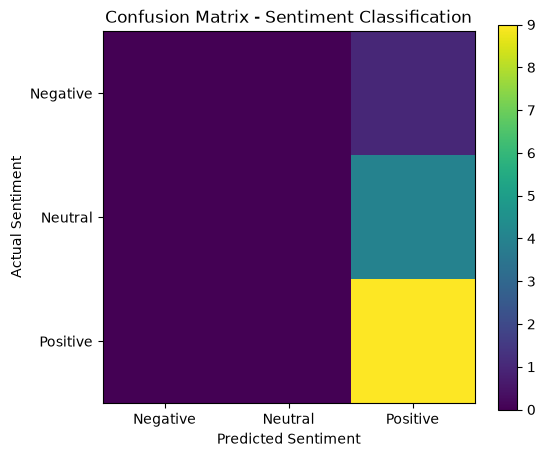

In [64]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix - Sentiment Classification")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.xticks(range(3), ["Negative", "Neutral", "Positive"])
plt.yticks(range(3), ["Negative", "Neutral", "Positive"])

plt.colorbar()

plt.savefig("confusion_matrix.png")
plt.show()

In [65]:
new_text = [
    "I am very happy with my new phone",
    "Today was a terrible and disappointing day",
    "I went to the market in the morning"
]

In [66]:
new_text_tfidf = vectorizer.transform(new_text)

In [67]:
new_predictions = model.predict(new_text_tfidf)

In [68]:
for text, prediction in zip(new_text, new_predictions):
    print("Text:", text)
    print("Predicted Sentiment:", prediction)
    print("-----------------------------")

Text: I am very happy with my new phone
Predicted Sentiment: Positive
-----------------------------
Text: Today was a terrible and disappointing day
Predicted Sentiment: Positive
-----------------------------
Text: I went to the market in the morning
Predicted Sentiment: Positive
-----------------------------


In [70]:
results = pd.DataFrame({
    "Text": new_text,
    "Predicted_Sentiment": new_predictions
})

results.to_csv("test_predictions.csv", index=False)

results

,Text,Predicted_Sentiment
0,I am very happy with my new phone,Positive
1,Today was a terrible and disappointing day,Positive
2,I went to the market in the morning,Positive


In [71]:
print("Dataset rows:", len(df))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of TF-IDF features:", X_train_tfidf.shape[1])
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Dataset rows: 67
Training samples: 53
Testing samples: 14
Number of TF-IDF features: 211
Accuracy: 0.6428571428571429
Precision: 0.41326530612244905
Recall: 0.6428571428571429
F1 Score: 0.5031055900621119


In [72]:
df.to_csv("cleaned_sentiment_dataset.csv", index=False)